In [17]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import stckit as stk

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'DejaVu Sans', 'Liberation Sans', 'Nimbus Sans'], 
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'svg.fonttype': 'none',
})

celltype_colors = ['#ffb750', '#a6d997', '#dff1f8', '#9fb2d2', '#fa7183', '#e4cde5',  
                   '#e8ddec', '#eff1c0', '#eb2624', '#dcf1ce', '#5f83c4', '#d5f4fb',
                   '#c9a86c', '#f4a6a5', '#a8d5e5', '#b8e0d2', '#d4a5d4', '#f9e4b7']

In [ ]:
# Load data
np.random.seed(42)

groupby = 'cell_type'
gene_target = 'mixed_pbmc'
gene_diffusion = [f'hashtag{i}' for i in range(1, 5)]

# Exclude control populations
exclude = ['Isotype', 'HTO']

adata = sc.read_h5ad('../data/Y10009L7_annotated.h5ad')
adata = adata[~adata.obs[groupby].isin(exclude)]

2026-04-14 17:04:25,424 - INFO - Loading data from ../data/Y10009L7_raw.h5ad...
/Data/user/zhuqianhua/01.bins/miniconda3/envs/dev/lib/python3.9/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/Data/user/zhuqianhua/01.bins/miniconda3/envs/dev/lib/python3.9/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
2026-04-14 17:04:25,683 - INFO - Using cell_target='dapi'
2026-04-14 17:04:25,683 - WARNING - Layer 'counts' not found. Falling back to adata.X
2026-04-14 17:04:25,729 - INFO - Secondary target identification skipped (max_diffusion_rate >= 1.0)
2026-04-14 17:04:25,730 - INFO - Target: cell_target='dapi'
2026-04-14 17:04:25,730 - INFO - Diffusion genes: ['hashtag1', 'hashtag2', 'hashtag3', 'hashtag4']
2026-04-14 17:04:25,730 - INFO - T

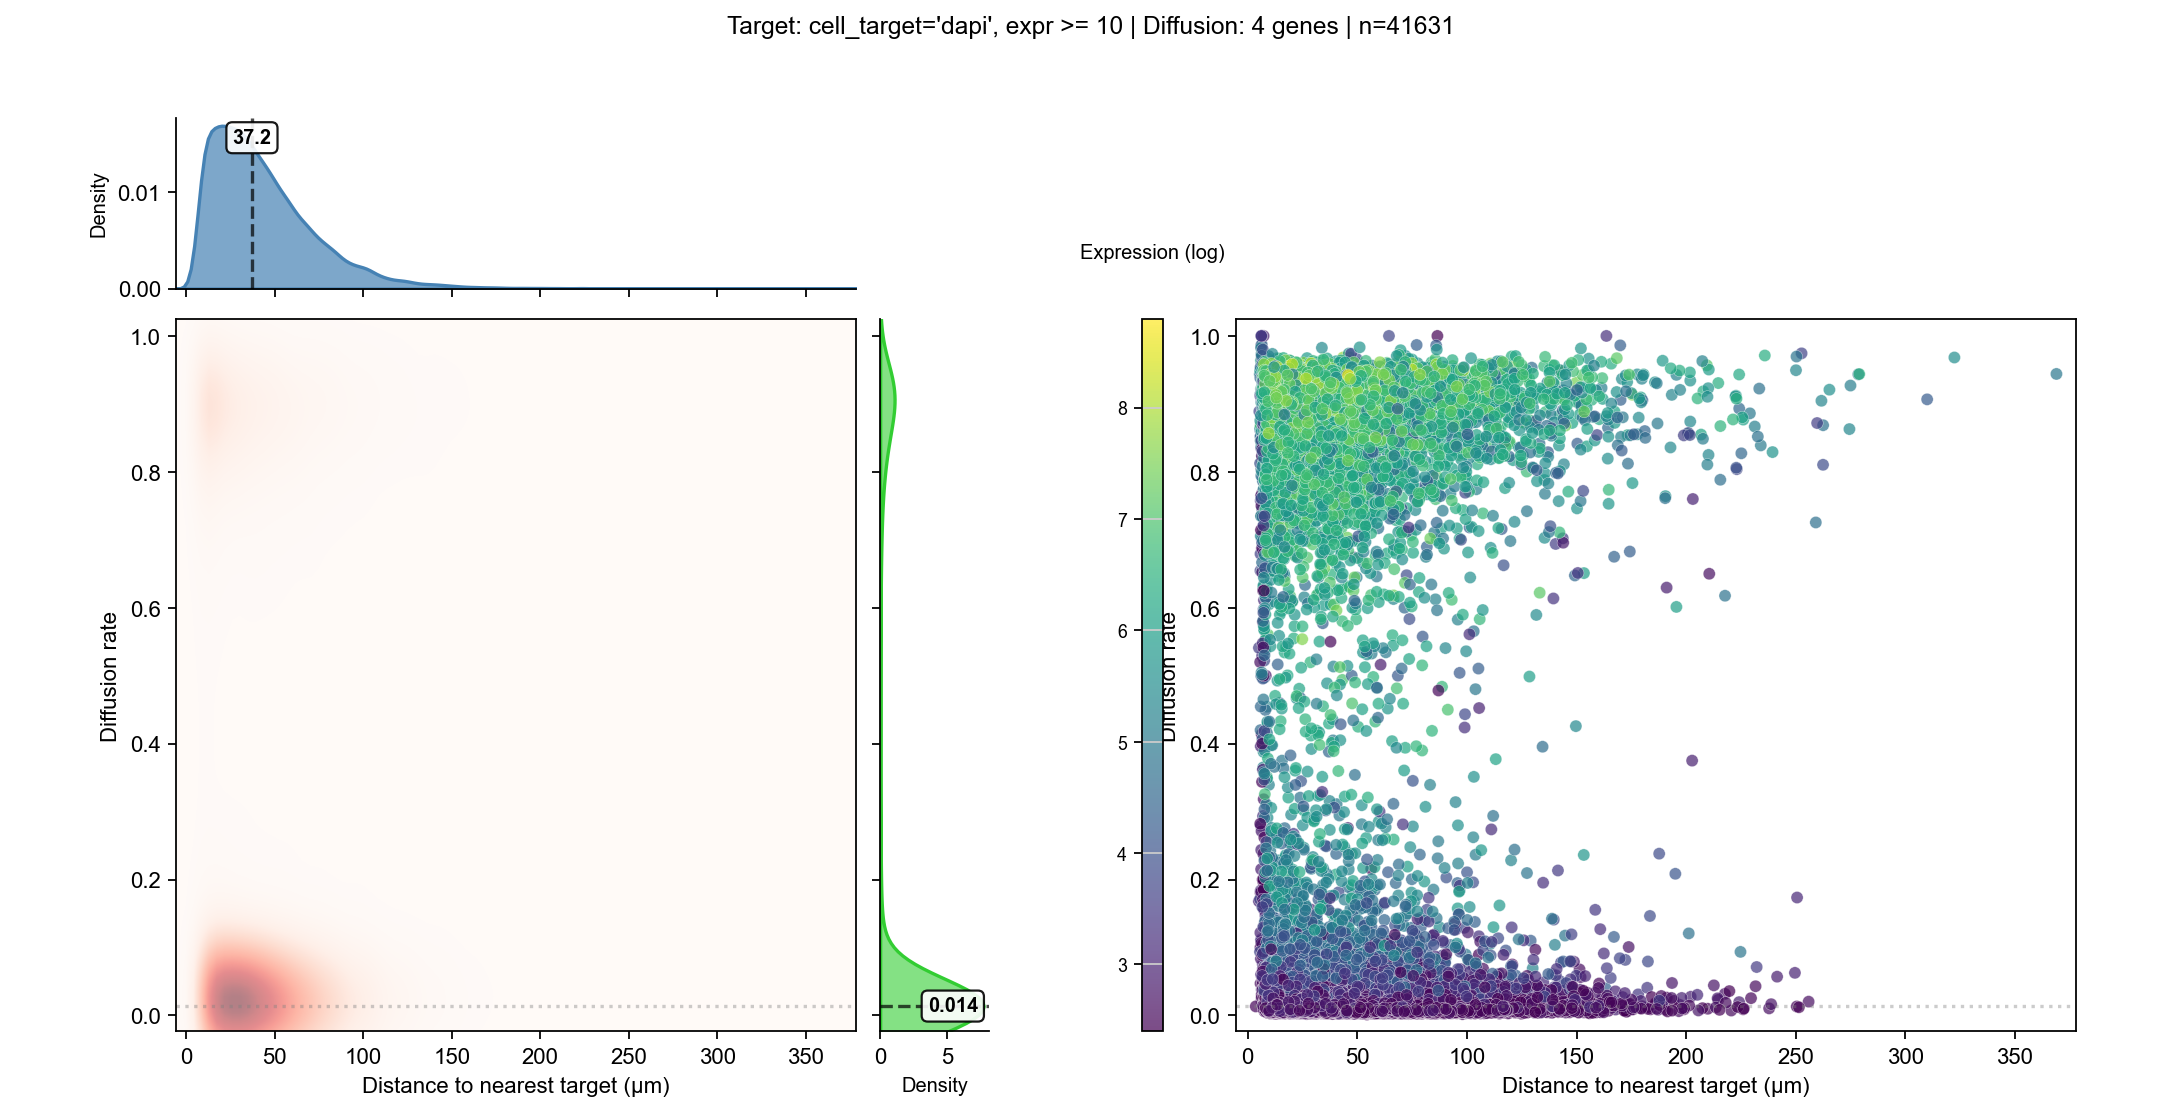

In [20]:
# Track dapi+ cell diffusion into HTO-labeled populations
stk.pl.plot_diffusion(
    '../data/Y10009L7_raw.h5ad',
    cell_target='dapi',
    gene_diffusion=gene_diffusion,
    min_diffusion_expr=10,
    show=True,
    use_contour=False
)

2026-04-14 17:04:49,812 - INFO - Loading data from ../data/Y10009L7_raw.h5ad
/Data/user/zhuqianhua/01.bins/miniconda3/envs/dev/lib/python3.9/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/Data/user/zhuqianhua/01.bins/miniconda3/envs/dev/lib/python3.9/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
2026-04-14 17:04:50,103 - INFO - Found 7928 target cells and 176952 non-target cells
2026-04-14 17:04:50,104 - INFO - Target genes: 4, Non-target genes: 164
2026-04-14 17:04:50,185 - INFO - Retained 162 non-target genes (<= p99, removed 2 outliers)
2026-04-14 17:04:50,185 - INFO - Sampled 100 non-target genes for visualization
2026-04-14 17:04:50,269 - INFO - Target genes count: 4
2026-04-14 17:04:50,270 - INFO - Non-target genes count (

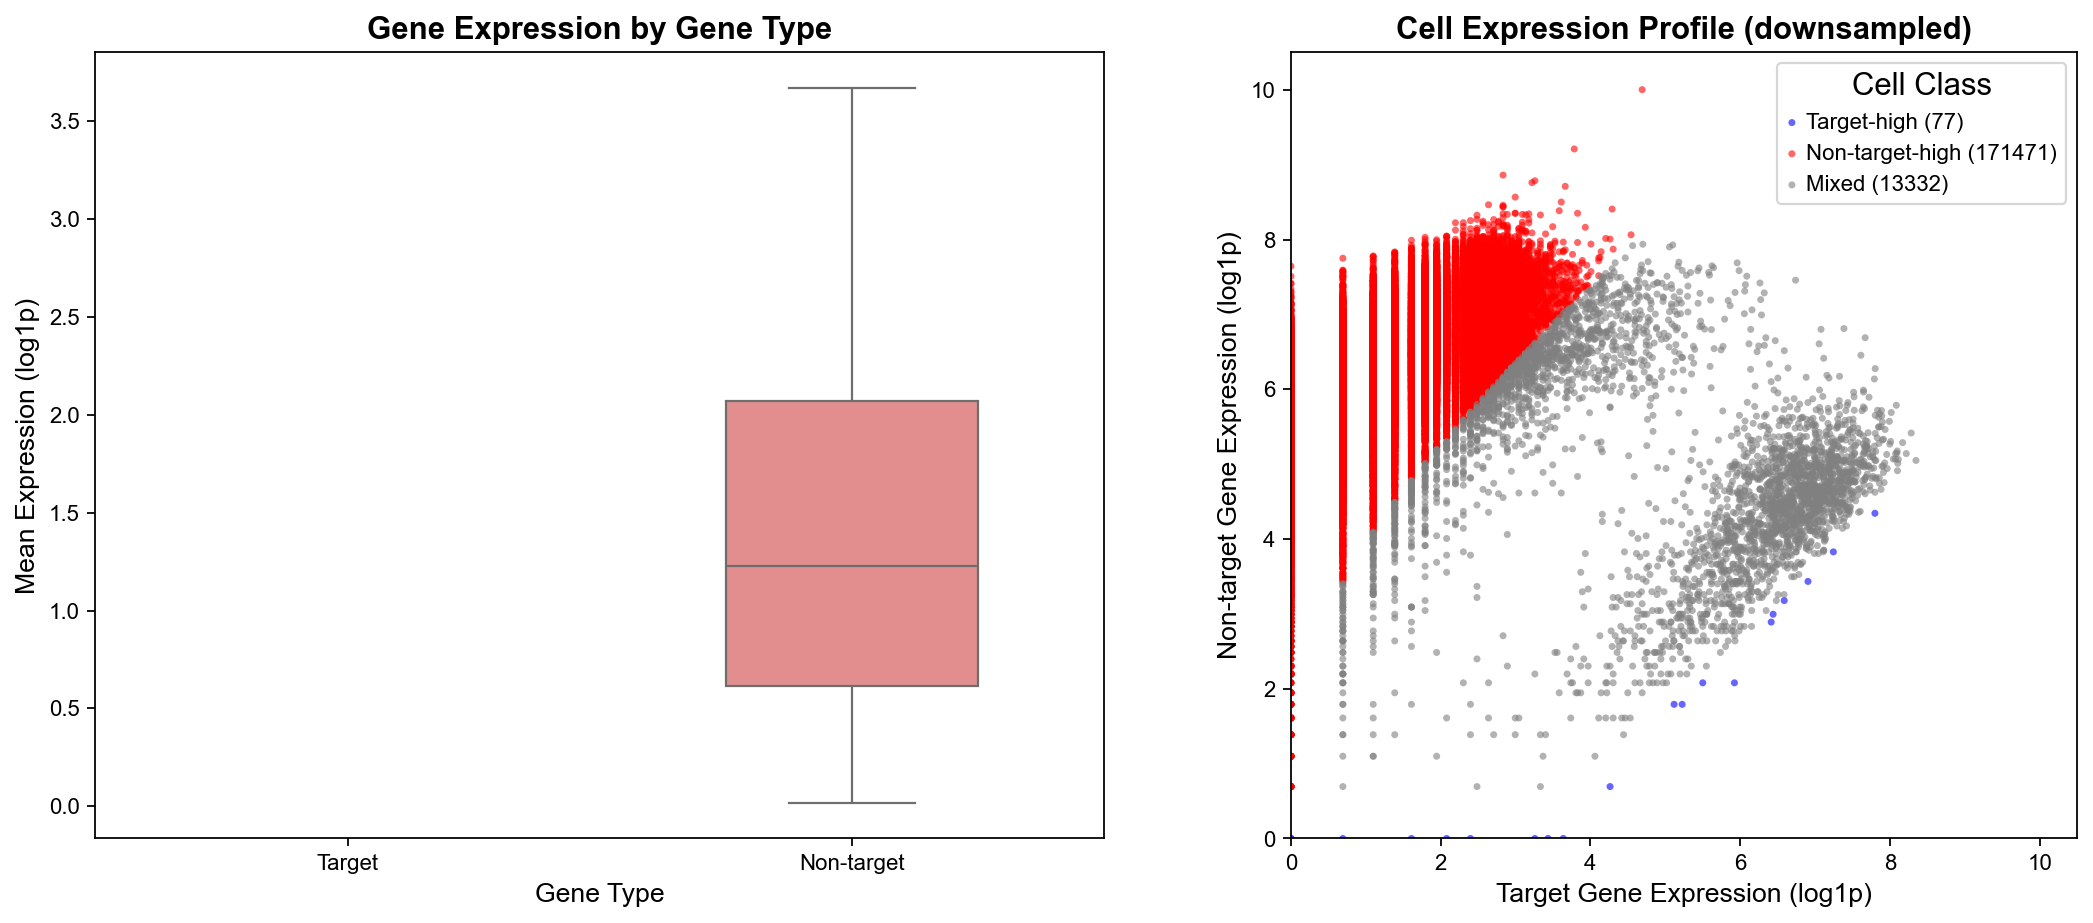

In [21]:
# Measure HTO abundance in dapi+ cells (cross-contamination detection)
stk.pl.gene_abundance(
    '../data/Y10009L7_raw.h5ad',
    target_gene=gene_diffusion,
    target_cell='dapi',
    slope_threshold=30,
    show=True
)

/Data/user/zhuqianhua/01.bins/miniconda3/envs/dev/lib/python3.9/site-packages/scanpy/plotting/_utils.py:487: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + "_colors"] = colors_list


<Axes: title={'center': 'Cell type'}, xlabel='UMAP1', ylabel='UMAP2'>

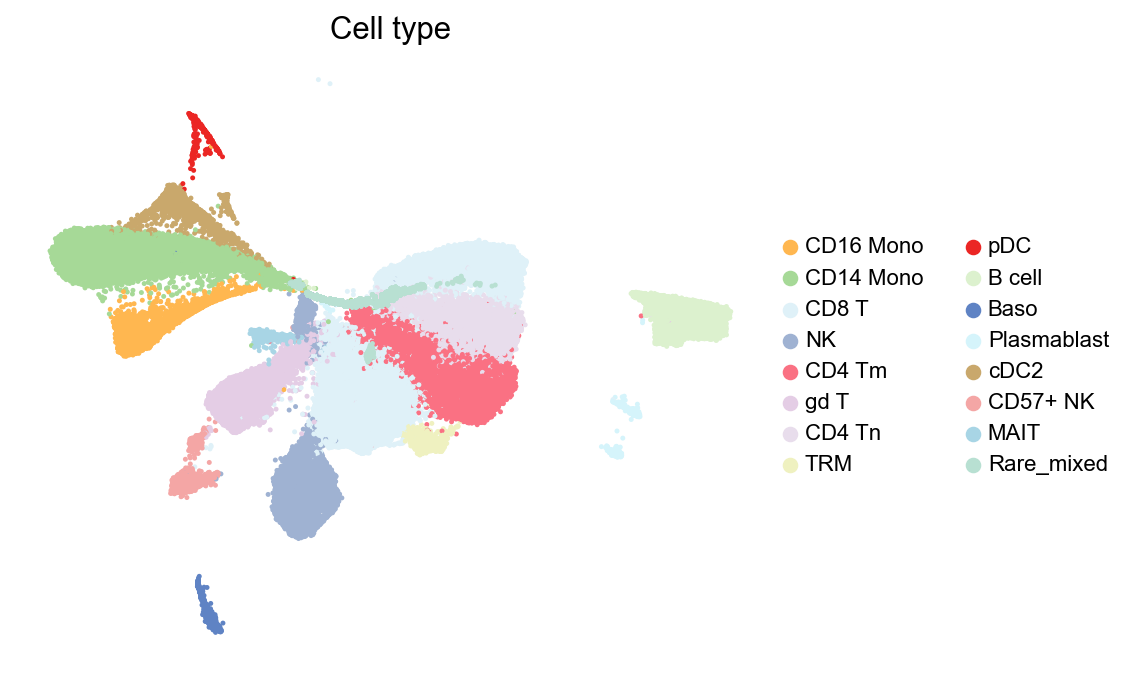

In [ ]:
# UMAP colored by annotated cell types
stk.pl.plot_umap(adata, groupby=groupby, color_map=celltype_colors, title='Cell type')

<Axes: title={'center': 'Cell type'}>

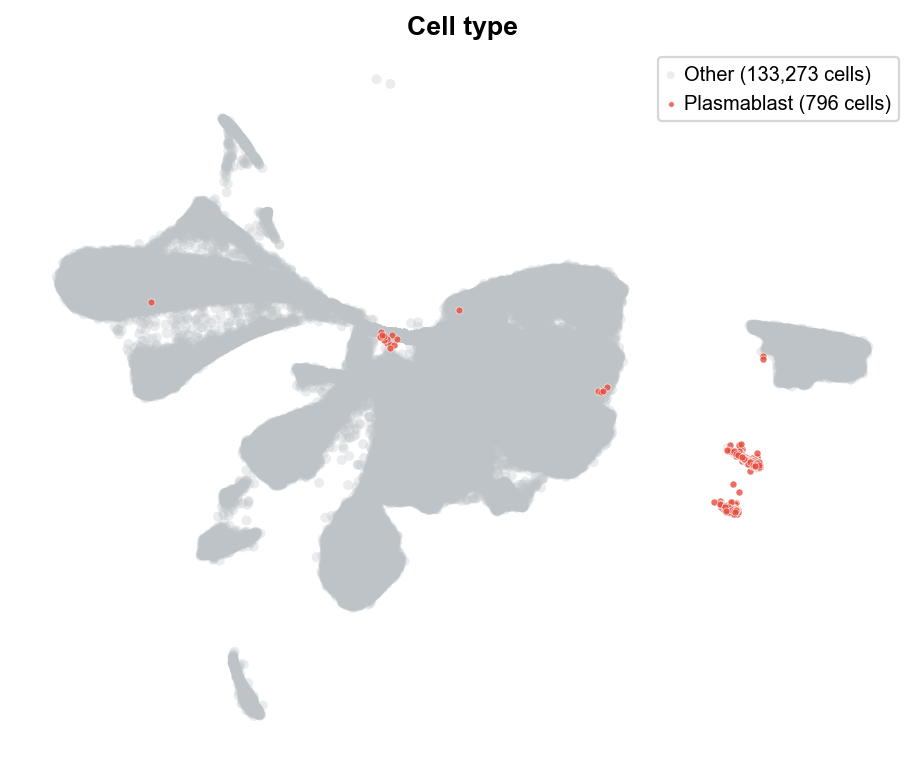

In [ ]:
# Highlight Plasmablast subset on UMAP
stk.pl.plot_subset(adata, groupby=groupby, subset='Plasmablast', subset_size=10, title='Cell type')

<Axes: title={'center': 'Cell type'}>

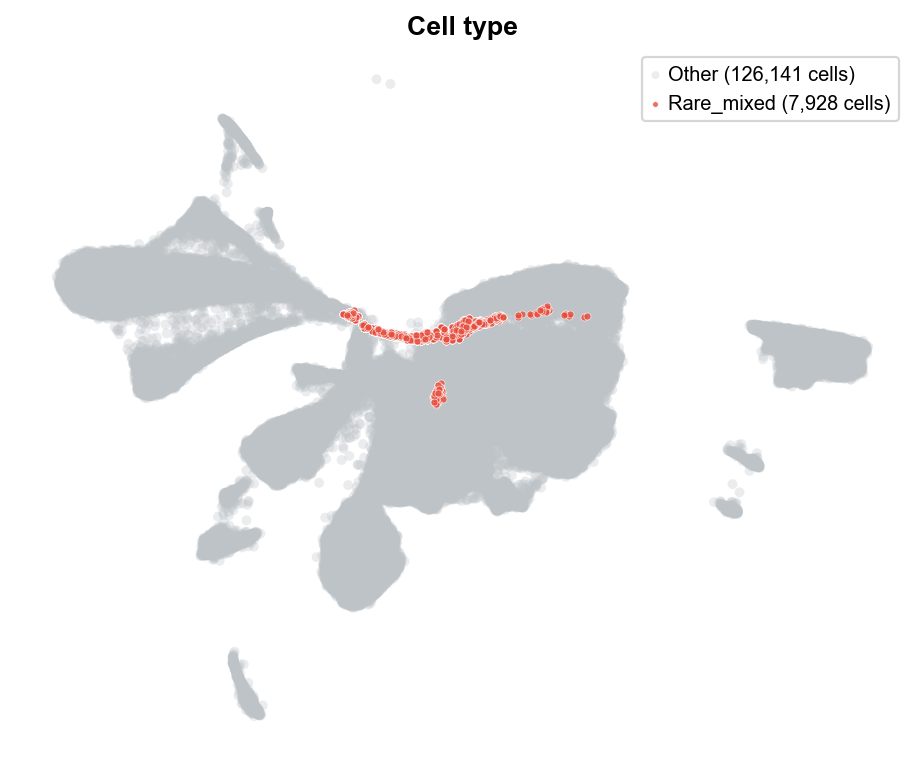

In [ ]:
# Highlight Rare_mixed subset on UMA
stk.pl.plot_subset(adata=adata, groupby=groupby, subset='Rare_mixed', subset_size=10, title='Cell type')

2026-04-14 16:54:43,310 - INFO - Excluded 7928 cells starting with 'dapi', retained 126141/134069 cells for analysis
2026-04-14 16:54:43,310 - INFO - Using expression data from layer='counts'
2026-04-14 16:54:43,344 - INFO - Downsampled spatial plot from 126141 to 50000 points (39.6%)


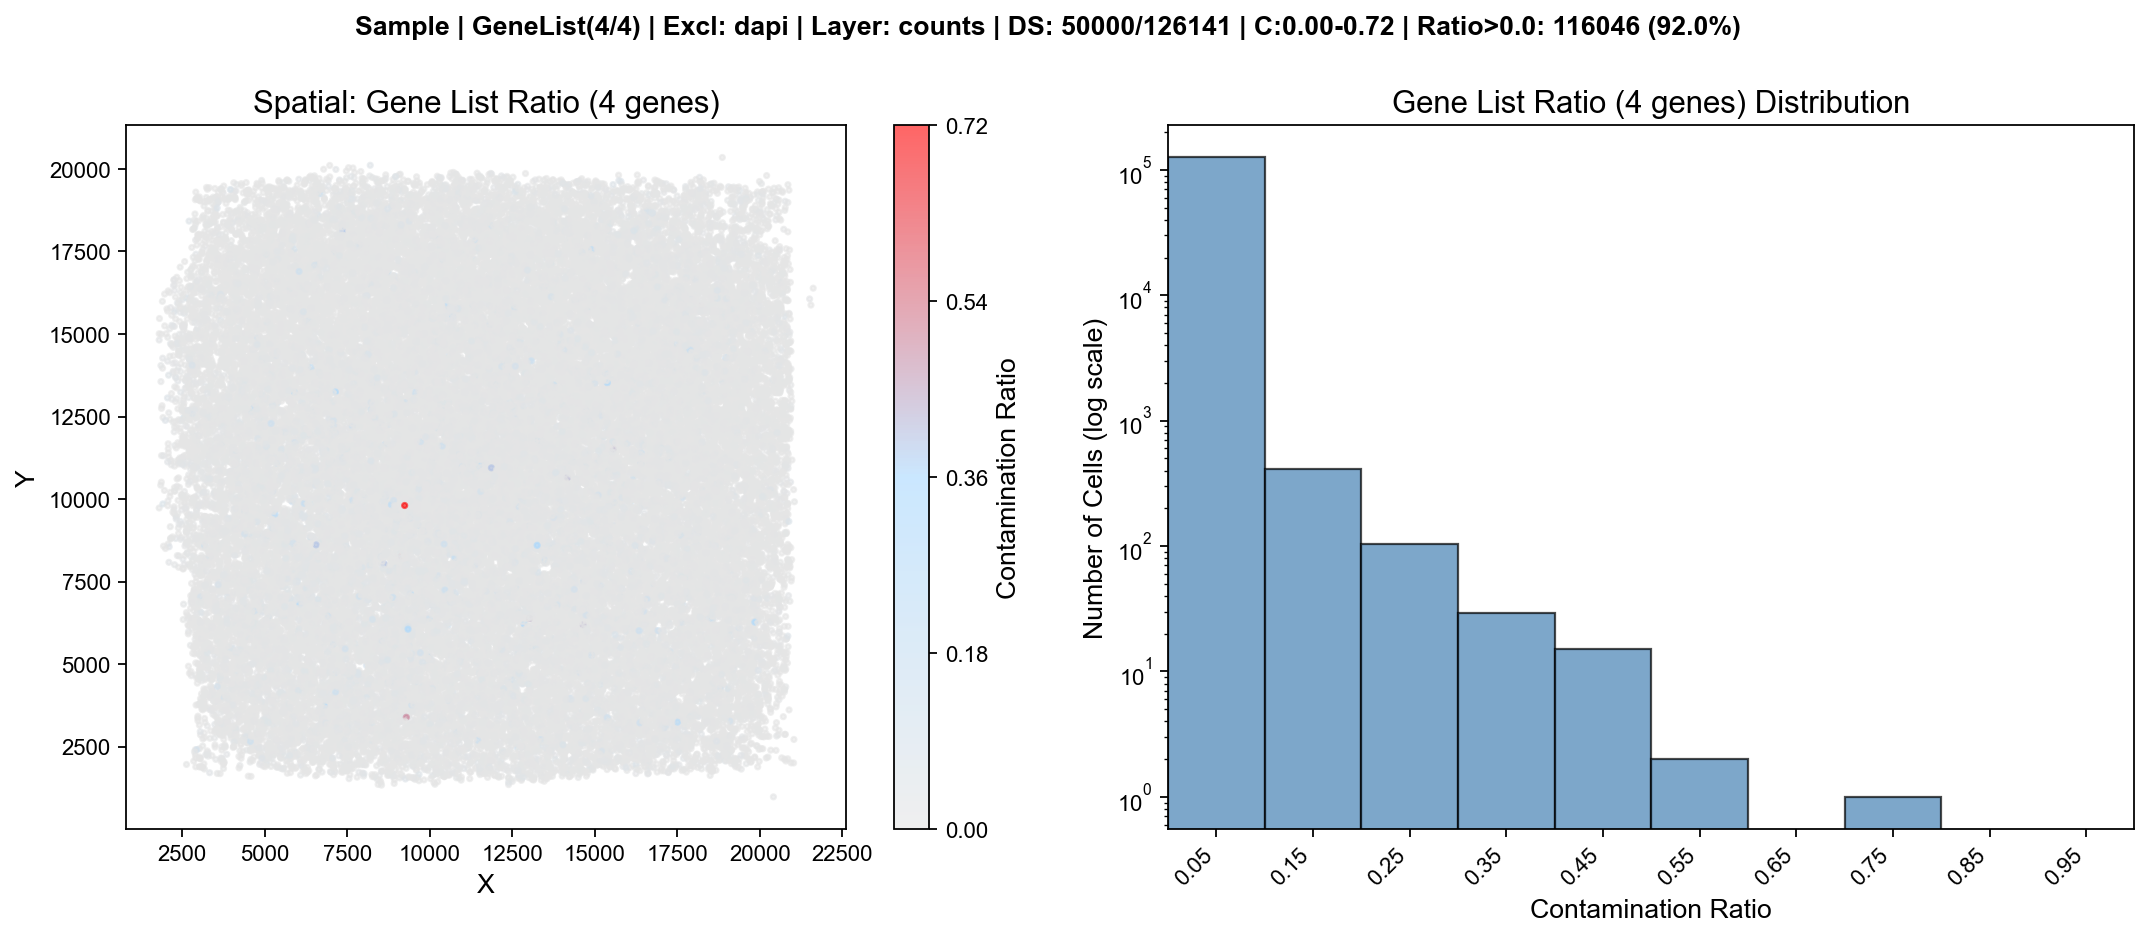

In [ ]:
# Assess cross-contamination: HTO signal in dapi+ cells
stk.pl.plot_contamination(adata, target_cell='dapi', gene_list=gene_diffusion)

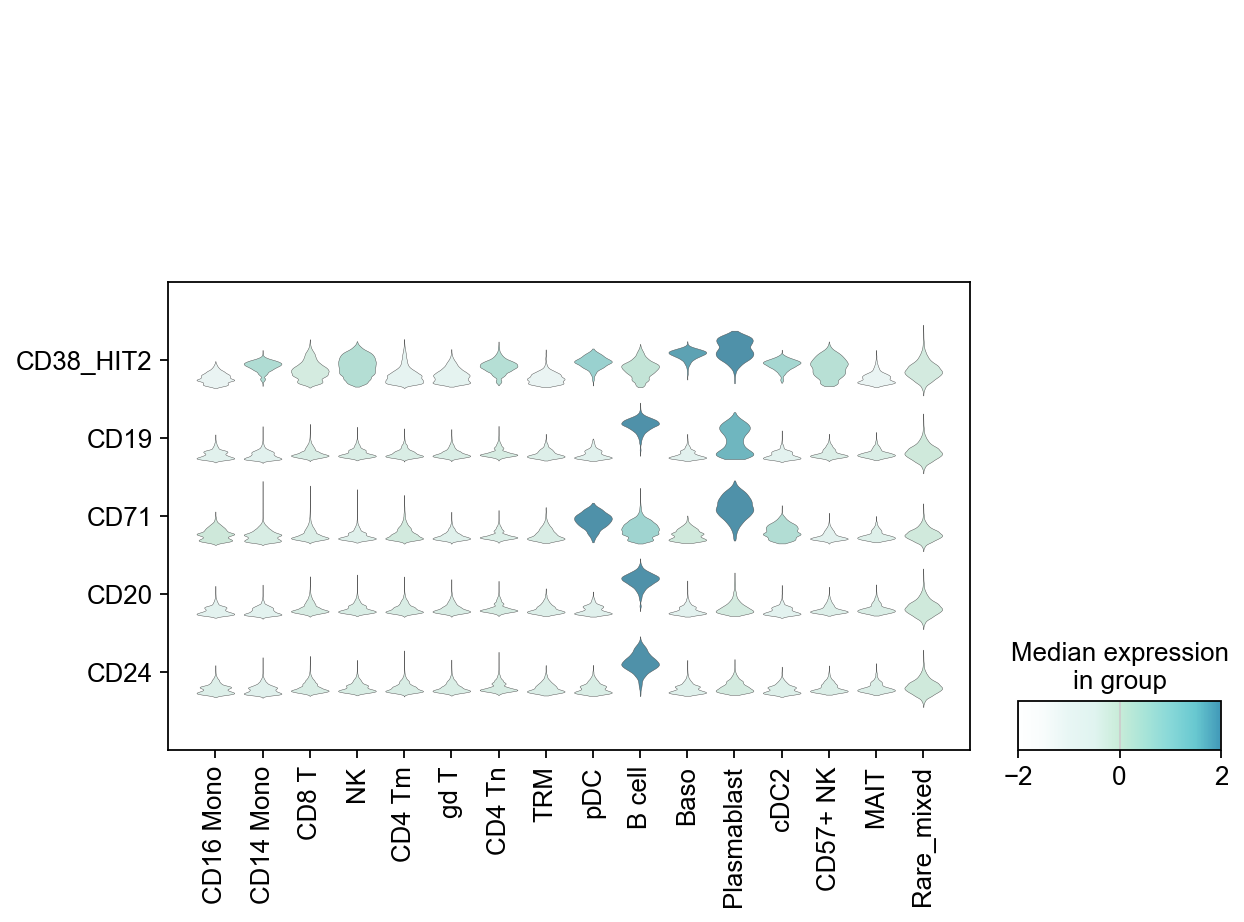

In [ ]:
def draw_stack(adata, output=None):
    """Draw stacked violin plot for B cell lineage markers."""
    # Custom colormap for gene expression
    cmap_genes = mcolors.LinearSegmentedColormap.from_list(
        "vivid_mid",
        ["#ffffff", "#f8fcfc", "#e8f6f4", "#e0f4f0", "#c8ecd8", 
         "#a8e4d8", "#88d8d8", "#68c8d0", "#4098b8"]
    )

    fig, ax = plt.subplots(figsize=(8, 6))
    
    # Scale data for visualization
    adata_plot = adata.copy()
    sc.pp.scale(adata_plot, max_value=10)
    
    # B cell differentiation markers
    gene_list = ["CD38_HIT2", "CD19", "CD71", "CD20", "CD24"]
    
    sc.pl.stacked_violin(
        adata_plot, 
        var_names=gene_list, 
        groupby='cell_type', 
        cmap=cmap_genes, 
        vmax=2, 
        vmin=-2,
        ax=ax, 
        show=False, 
        swap_axes=True, 
        dendrogram=False
    )
    
    plt.tight_layout()
    if output:
        plt.savefig(output, dpi=300)
    plt.show()
    plt.close()


# Generate B cell marker expression plot
draw_stack(adata)

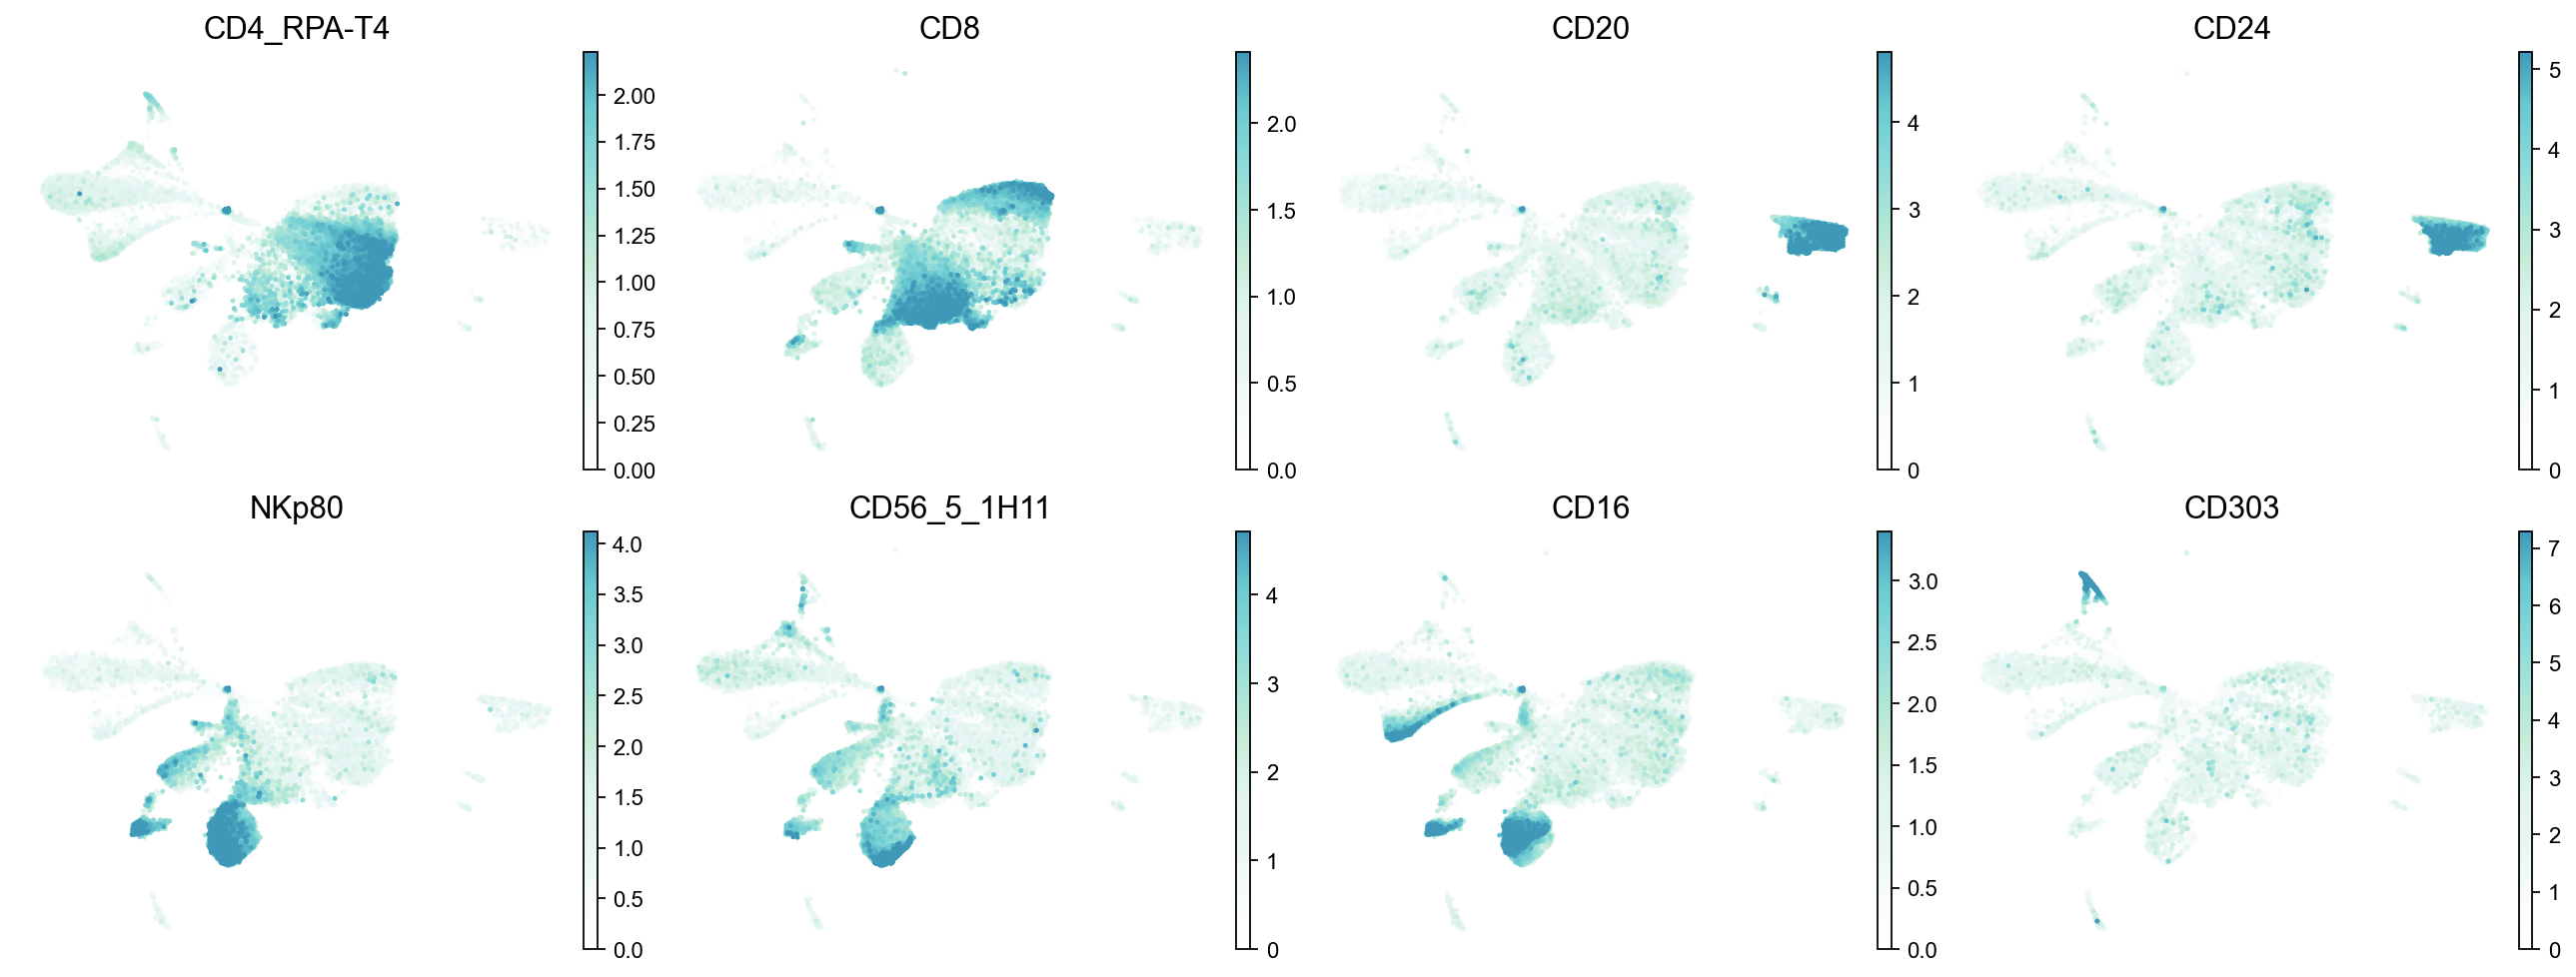

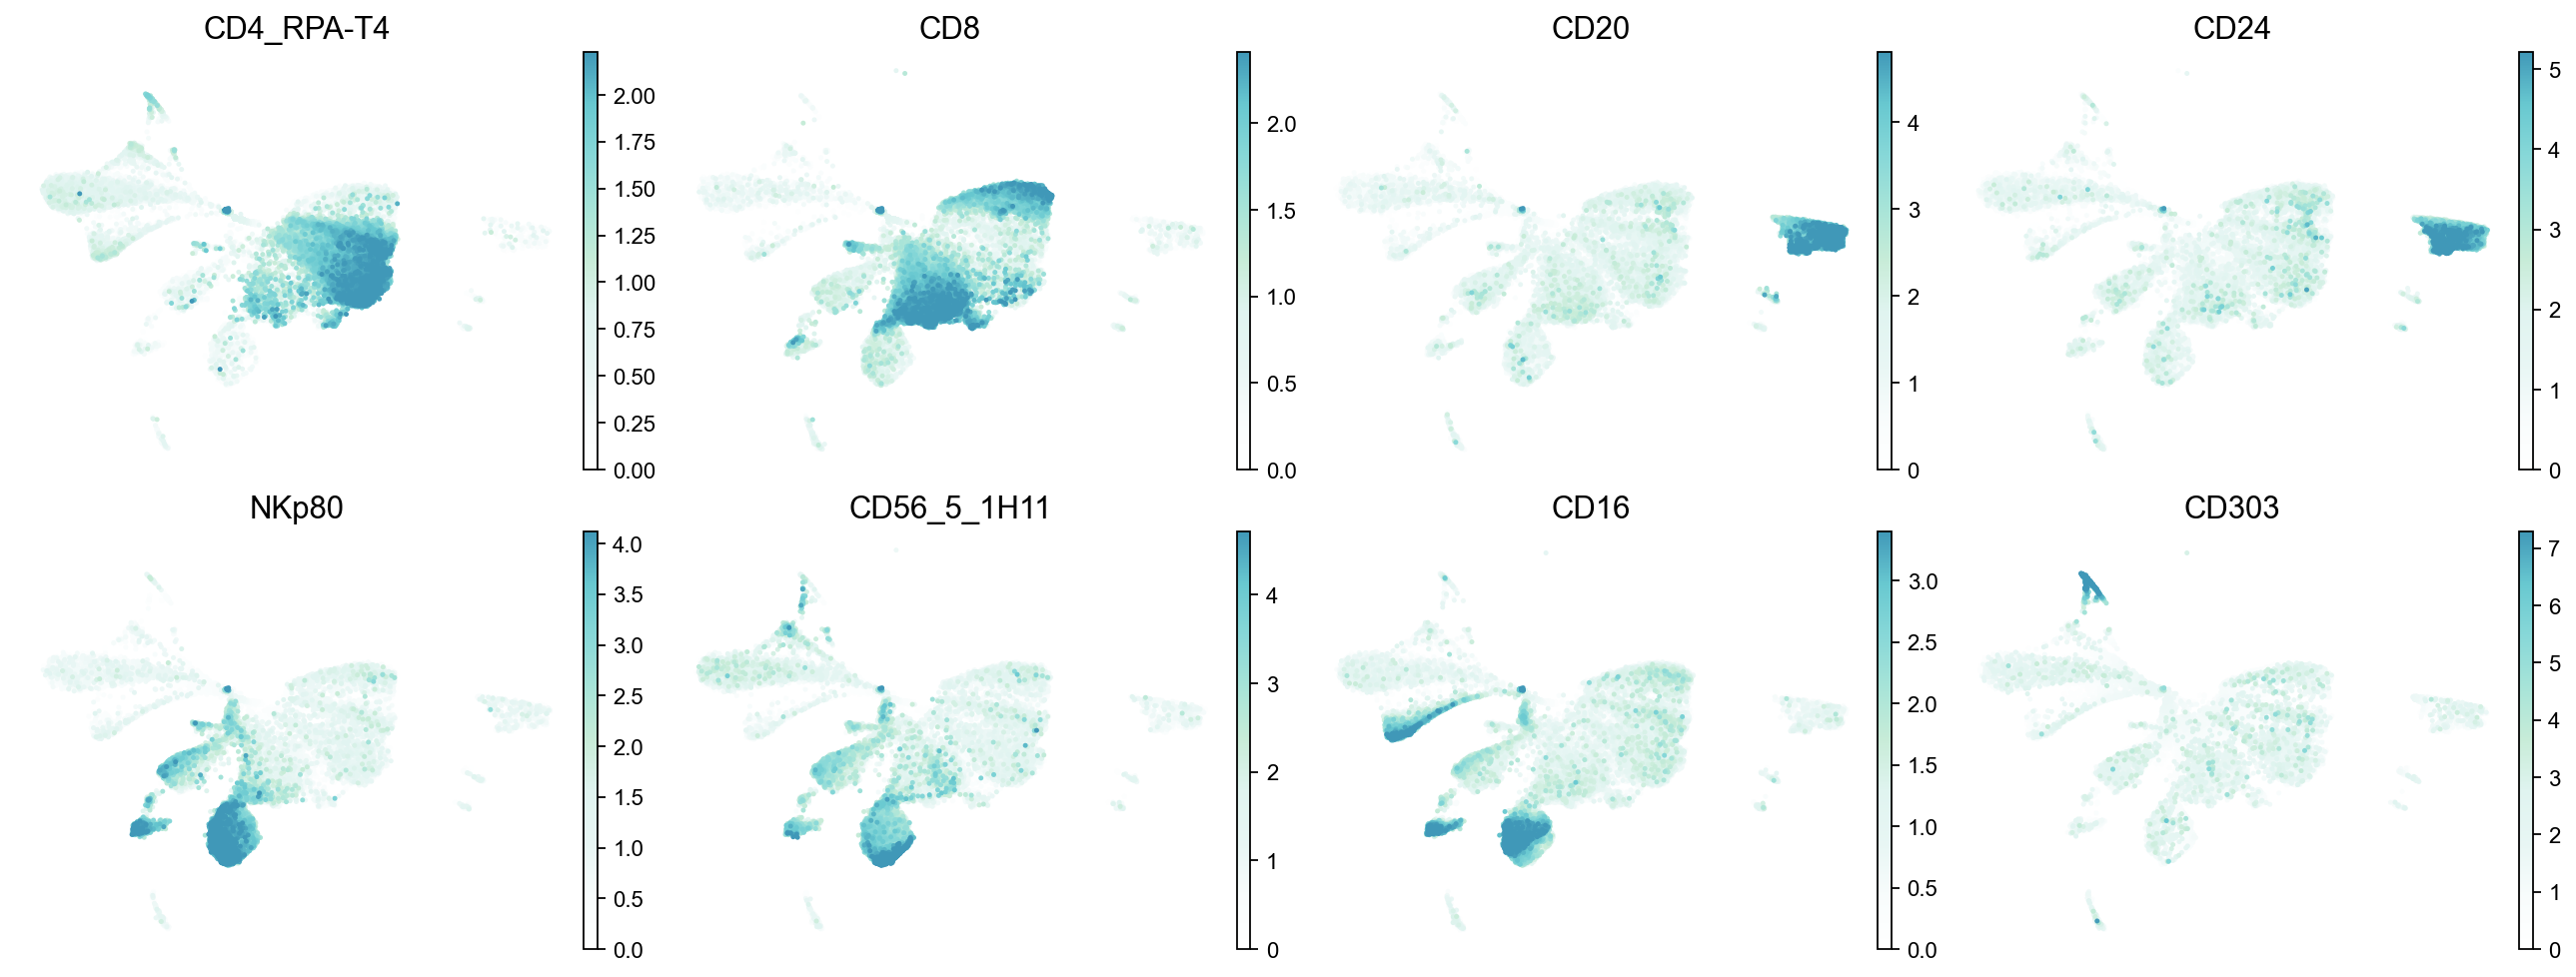

In [ ]:
# Custom teal-blue colormap for protein expression
cmap_genes = mcolors.LinearSegmentedColormap.from_list(
    "vivid_mid",
    ["#ffffff", "#f8fcfc", "#e8f6f4", "#e0f4f0", "#c8ecd8",
     "#a8e4d8", "#88d8d8", "#68c8d0", "#4098b8"]
)

# Key lineage markers: CD4/8 T, B, NK, Mono, pDC
markers = [
    "CD4_RPA-T4", "CD8",           # T cells
    "CD20", "CD24",                # B cells
    "NKp80", "CD56_5_1H11",        # NK cells
    "CD16",                        # Monocytes
    "CD303"                        # pDC
]

# Multi-panel feature plot
stk.pl.plot_genes(adata, genes=markers, ncols=4, cmap=cmap_genes)